# NER on Kazakh–Russian public transport complaints: training and representation-space analysis

This notebook contains:

- **Part 1 (cells 1–8).** Training and evaluation pipeline for the XLM-RoBERTa NER model from our IEEE SIST 2026 paper ([DOI: 10.1109/SIST61674.2026.11596166](https://doi.org/10.1109/SIST61674.2026.11596166)).
- **Part 2 (cells 9–15).** Follow-up analysis: does the position of a complaint in the encoder's representation space predict NER errors beyond simple baselines (length, language, model confidence)?
- **Part 3 (cell 16).** Train–test shift measured with the sliced Wasserstein distance (optimal transport), for complaints containing street names vs. stop names.
- **Part 4 (cell 17).** Statistical controls for Part 3: entity-level embeddings, permutation test, size-matched null, frozen vs. fine-tuned encoder.

**Data.** The annotated complaints are not included in this repository because of data-sharing restrictions. The notebook expects two files, `train.jsonl` and `test.jsonl`, with pre-tokenized `input_ids`, `attention_mask` and `labels` (first-subword labeling, other subwords set to -100).

**How to run.** Google Colab with a GPU runtime (T4 is enough). Upload the two data files and run the cells in order. To use a re-stratified split, first run `scripts/make_stratified_split.py` and change `TRAIN_FILE` / `TEST_FILE` in cell 2.

See `README.md` for results and known limitations.

In [5]:
# Cell 1 (fallback). Use seqeval from source without building it
!pip install -q umap-learn pot
!wget -q https://files.pythonhosted.org/packages/source/s/seqeval/seqeval-1.2.2.tar.gz -O /content/seqeval.tar.gz
!tar -xzf /content/seqeval.tar.gz -C /content
import sys
sys.path.insert(0, "/content/seqeval-1.2.2")
import seqeval
print("seqeval loaded from", seqeval.__file__)

seqeval loaded from /content/seqeval-1.2.2/seqeval/__init__.py


In [6]:
# Cell 2. Imports and configuration
import json
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim import AdamW
from transformers import (
    XLMRobertaForTokenClassification,
    XLMRobertaTokenizer,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import classification_report
from seqeval.metrics.sequence_labeling import get_entities
from collections import Counter
from scipy.stats import spearmanr, mannwhitneyu

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Note: GPU training is not fully deterministic, so per-class F1 can vary between runs.
# Report means over several seeds when comparing numbers.

TRAIN_FILE = "train.jsonl"
TEST_FILE = "test.jsonl"

BATCH_SIZE = 8
EPOCHS = 9
LEARNING_RATE = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [7]:
# Cell 3. Label set (BIO scheme, six entity types)
id2label = {
    0: "O",
    1: "B-ROUTE_NUM", 2: "I-ROUTE_NUM",
    3: "B-BUS_ID", 4: "I-BUS_ID",
    5: "B-PLATE_NUM", 6: "I-PLATE_NUM",
    7: "B-STOP_NAME", 8: "I-STOP_NAME",
    9: "B-STREET_NAME", 10: "I-STREET_NAME",
    11: "B-STREET_INTERSECTION", 12: "I-STREET_INTERSECTION",
}
label2id = {v: k for k, v in id2label.items()}

In [14]:
# Cell 4. Dataset and data loaders
import os

def find_file(name):
    """Look for a data file in the usual Colab locations."""
    for folder in ["/content", "/", "/content/sample_data", "/content/drive/MyDrive/ner_data"]:
        path = os.path.join(folder, os.path.basename(name))
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"{name} not found. Upload it via the Files panel.")

TRAIN_FILE = find_file(TRAIN_FILE)
TEST_FILE = find_file(TEST_FILE)
print("Using:", TRAIN_FILE, "|", TEST_FILE)


class NerDataset(Dataset):
    def __init__(self, file_path):
        self.data = []
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                self.data.append(json.loads(line))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(item["labels"], dtype=torch.long),
        }


def collate_fn(batch):
    input_ids = pad_sequence([b["input_ids"] for b in batch],
                             batch_first=True, padding_value=1)   # XLM-R pad id
    attention_mask = pad_sequence([b["attention_mask"] for b in batch],
                                  batch_first=True, padding_value=0)
    labels = pad_sequence([b["labels"] for b in batch],
                          batch_first=True, padding_value=-100)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


train_dataset = NerDataset(TRAIN_FILE)
test_dataset = NerDataset(TEST_FILE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate_fn)
print("train:", len(train_dataset), "| test:", len(test_dataset))

Using: /train.jsonl | /test.jsonl
train: 1925 | test: 825


In [15]:
# Cell 5. Class weights
# Classes are strongly imbalanced, so the loss is weighted by inverse label frequency.
# STREET_NAME gets an extra factor of 1.6. Note: there is no validation set, so this
# factor was effectively tuned on the test set (see README, Limitations).
label_counter = Counter()
for sample in train_dataset:
    for label in sample["labels"]:
        if label != -100:
            label_counter[label.item()] += 1

total_tokens = sum(label_counter.values())
num_classes = len(id2label)
class_weights = []
for i in range(num_classes):
    count = label_counter.get(i, 1)
    class_weights.append(total_tokens / (num_classes * count))

class_weights = torch.tensor(class_weights).to(DEVICE)
class_weights[label2id["B-STREET_NAME"]] *= 1.6
class_weights[label2id["I-STREET_NAME"]] *= 1.6

In [16]:
# Cell 6. Model, optimizer, loss
model = XLMRobertaForTokenClassification.from_pretrained(
    "xlm-roberta-base", num_labels=len(id2label))
model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0,
    num_training_steps=len(train_loader) * EPOCHS)
loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
# Cell 7. Training (about 10-20 minutes on a T4)
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        inputs = {"input_ids": batch["input_ids"].to(DEVICE),
                  "attention_mask": batch["attention_mask"].to(DEVICE)}
        labels = batch["labels"].to(DEVICE)
        outputs = model(**inputs)
        loss = loss_fct(outputs.logits.view(-1, model.config.num_labels),
                        labels.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/9 | Loss: 1.1785
Epoch 2/9 | Loss: 0.4494
Epoch 3/9 | Loss: 0.3366
Epoch 4/9 | Loss: 0.3271
Epoch 5/9 | Loss: 0.2843
Epoch 6/9 | Loss: 0.1775
Epoch 7/9 | Loss: 0.1812
Epoch 8/9 | Loss: 0.1425
Epoch 9/9 | Loss: 0.0872


In [18]:
# Cell 8. Evaluation: entity-level exact span matching (seqeval)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        inputs = {"input_ids": batch["input_ids"].to(DEVICE),
                  "attention_mask": batch["attention_mask"].to(DEVICE)}
        labels = batch["labels"].to(DEVICE)
        preds = torch.argmax(model(**inputs).logits, dim=2)
        for i in range(len(labels)):
            sp, sl = [], []
            for j in range(len(labels[i])):
                if labels[i][j] != -100:
                    sp.append(id2label[preds[i][j].item()])
                    sl.append(id2label[labels[i][j].item()])
            all_preds.append(sp)
            all_labels.append(sl)

print(classification_report(all_labels, all_preds, digits=4))

/content/seqeval-1.2.2/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                     precision    recall  f1-score   support

             BUS_ID     0.8991    0.6386    0.7468       321
          PLATE_NUM     0.5342    0.8540    0.6573       137
          ROUTE_NUM     0.8742    0.9614    0.9158       752
          STOP_NAME     0.5257    0.8302    0.6437       530
STREET_INTERSECTION     0.0000    0.0000    0.0000         6
        STREET_NAME     0.3162    0.2067    0.2500       208

          micro avg     0.6800    0.7820    0.7274      1954
          macro avg     0.5249    0.5818    0.5356      1954
       weighted avg     0.6979    0.7820    0.7224      1954



## Part 2. Representation geometry vs. NER errors

Each complaint is mapped to a vector (mean over its token representations) at several encoder layers. Hypothesis: complaints with NER errors lie farther from the centroid of their language cluster (Russian or Kazakh) computed on the training set.

The analysis adapts the representation-space analysis of Lin et al., *Towards Understanding Jailbreak Attacks in LLMs: A Representation Space Analysis* (EMNLP 2024), to multilingual sequence labeling.

**Result in our runs:** the hypothesis was **not** supported (see README).

In [24]:
# Cell 9. Language of each complaint (heuristic)
# A word counts as Kazakh if it contains a Kazakh-specific letter.
# kk: > 60% Kazakh words; ru: no Kazakh words; mixed: otherwise.
# Limitation: Kazakh words without Kazakh-specific letters are counted as Russian.
KAZ_CHARS = set("әғқңөұүіһӘҒҚҢӨҰҮІҺ")

def detect_lang(text):
    words = re.findall(r"[а-яёА-ЯЁәғқңөұүіһӘҒҚҢӨҰҮІҺ]+", text)
    if not words:
        return "other"
    kaz_words = sum(1 for w in words if any(c in KAZ_CHARS for c in w))
    ratio = kaz_words / len(words)
    if ratio == 0:
        return "ru"
    if ratio > 0.6:
        return "kk"
    return "mixed"

print(detect_lang("жүргізуші аялдамада тоқтамады"))                           # kk
print(detect_lang("водитель не остановился на остановке"))                    # ru
print(detect_lang("водитель не остановился на остановке Абылай хан даңғылы"))  # mixed

kk
ru
mixed


In [25]:
# Cell 10. One pass over the data: per-complaint metadata, NER quality and embeddings
#   lang          language label from cell 9
#   text_f1/error entity-level F1 on this complaint; error = 1 if F1 < 1
#   conf          mean max-softmax probability (model confidence baseline)
#   has_*         whether the complaint contains STOP_NAME / STREET_NAME
#   embeddings    mean-pooled hidden states at layers 0, 4, 8, 12
LAYERS = [0, 4, 8, 12]

def collect(loader):
    rows = []
    embs = {l: [] for l in LAYERS}
    model.eval()
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"]
            out = model(input_ids=input_ids, attention_mask=attn,
                        output_hidden_states=True)
            preds = torch.argmax(out.logits, dim=2).cpu()
            probs = torch.softmax(out.logits, dim=2).max(dim=2).values.cpu()

            mask = attn.unsqueeze(-1).float()
            for l in LAYERS:
                pooled = (out.hidden_states[l] * mask).sum(1) / mask.sum(1)
                embs[l].append(pooled.cpu().numpy())

            for i in range(input_ids.size(0)):
                text = tokenizer.decode(batch["input_ids"][i], skip_special_tokens=True)
                sp, sl, confs = [], [], []
                for j in range(len(labels[i])):
                    if labels[i][j] != -100:
                        sp.append(id2label[preds[i][j].item()])
                        sl.append(id2label[labels[i][j].item()])
                        confs.append(probs[i][j].item())
                gold = set(get_entities(sl))
                pred = set(get_entities(sp))
                gold_types = {g[0] for g in gold}
                tp = len(gold & pred)
                prec = tp / len(pred) if pred else (1.0 if not gold else 0.0)
                rec = tp / len(gold) if gold else 1.0
                f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
                rows.append({
                    "text": text,
                    "lang": detect_lang(text),
                    "n_tokens": len(sl),
                    "n_gold_entities": len(gold),
                    "conf": float(np.mean(confs)) if confs else 1.0,
                    "text_f1": f1,
                    "error": int(f1 < 1.0),
                    "has_STOP_NAME": int("STOP_NAME" in gold_types),
                    "has_STREET_NAME": int("STREET_NAME" in gold_types),
                })
    df = pd.DataFrame(rows)
    for l in LAYERS:
        embs[l] = np.vstack(embs[l])
    return df, embs

df_train, emb_train = collect(train_loader)
df_test, emb_test = collect(test_loader)
print(df_test["lang"].value_counts())
print("Share of test complaints with at least one error:", round(df_test["error"].mean(), 3))
# Do not print or save df["text"]: it contains the original complaint texts.

lang
ru       576
mixed    167
kk        82
Name: count, dtype: int64
Share of test complaints with at least one error: 0.595


In [26]:
# Cell 11. Cosine distances to language centroids
# Centroids are computed on the training set only.
def cos_dist_to(X, c):
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    cn = c / np.linalg.norm(c)
    return 1 - Xn @ cn

for l in LAYERS:
    cent = {}
    for lang in ["ru", "kk"]:
        idx = (df_train["lang"] == lang).values
        cent[lang] = emb_train[l][idx].mean(axis=0)
    d_ru = cos_dist_to(emb_test[l], cent["ru"])
    d_kk = cos_dist_to(emb_test[l], cent["kk"])
    df_test[f"d_ru_L{l}"] = d_ru
    df_test[f"d_kk_L{l}"] = d_kk
    # d_own: distance to the complaint's own language centroid (nearest one for mixed)
    df_test[f"d_own_L{l}"] = np.where(df_test["lang"] == "ru", d_ru,
                             np.where(df_test["lang"] == "kk", d_kk,
                                      np.minimum(d_ru, d_kk)))
    # d_gap: small gap = the complaint sits between the two language clusters
    df_test[f"d_gap_L{l}"] = np.abs(d_ru - d_kk)

layer |  rho(d_own,F1) |        p |  MWU p (err vs ok)
    0 |          0.113 |   0.0012 |             0.0000
    4 |          0.171 |   0.0000 |             0.0000
    8 |          0.196 |   0.0000 |             0.0000
   12 |          0.087 |   0.0122 |             0.0000


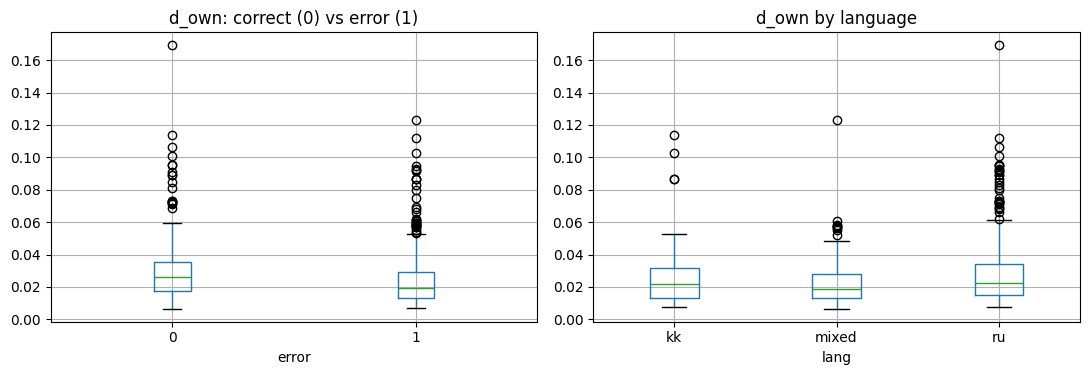

In [27]:
# Cell 12. Main test: are erroneous complaints farther from their language centroid?
# Hypothesis: negative Spearman correlation between d_own and text-level F1.
# All layers are reported; the plots use the last layer (fixed in advance, not selected
# by the results).
print(f"{'layer':>5} | {'rho(d_own,F1)':>14} | {'p':>8} | {'MWU p (err vs ok)':>18}")
for l in LAYERS:
    rho, p = spearmanr(df_test[f"d_own_L{l}"], df_test["text_f1"])
    a = df_test.loc[df_test.error == 1, f"d_own_L{l}"]
    b = df_test.loc[df_test.error == 0, f"d_own_L{l}"]
    _, p2 = mannwhitneyu(a, b, alternative="two-sided")
    print(f"{l:>5} | {rho:>14.3f} | {p:>8.4f} | {p2:>18.4f}")

PLOT_L = 12
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (grp, title) in zip(axes, [("error", "d_own: correct (0) vs error (1)"),
                                   ("lang", "d_own by language")]):
    df_test.boxplot(column=f"d_own_L{PLOT_L}", by=grp, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(grp)
plt.suptitle("")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


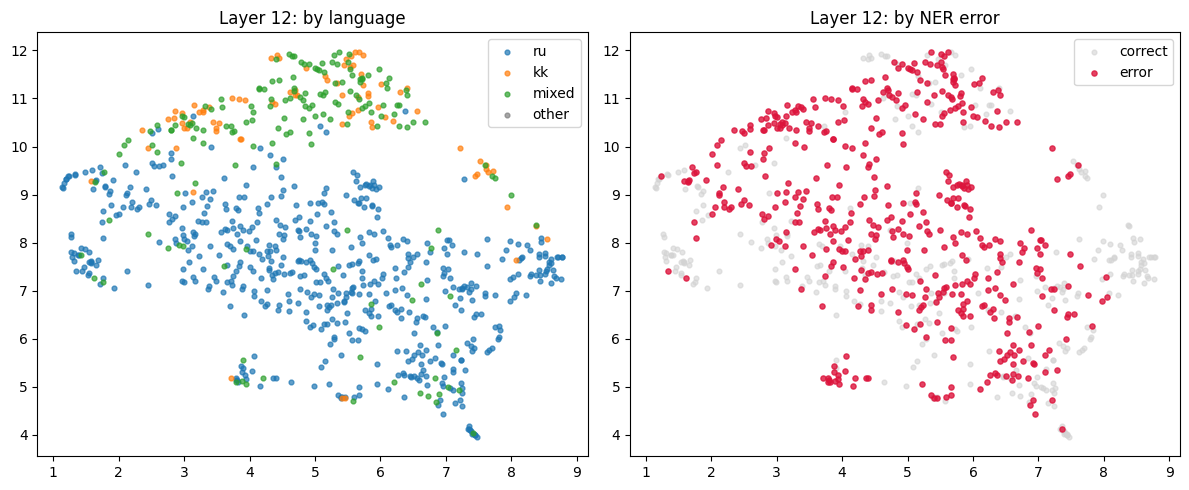

In [28]:
# Cell 13. UMAP projection of test complaints (layer PLOT_L)
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
xy = reducer.fit_transform(emb_test[PLOT_L])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"ru": "tab:blue", "kk": "tab:orange", "mixed": "tab:green", "other": "gray"}
for lang, c in colors.items():
    m = (df_test["lang"] == lang).values
    axes[0].scatter(xy[m, 0], xy[m, 1], s=12, c=c, label=lang, alpha=0.7)
axes[0].legend()
axes[0].set_title(f"Layer {PLOT_L}: by language")

m = df_test["error"].values == 1
axes[1].scatter(xy[~m, 0], xy[~m, 1], s=12, c="lightgray", label="correct", alpha=0.6)
axes[1].scatter(xy[m, 0], xy[m, 1], s=14, c="crimson", label="error", alpha=0.8)
axes[1].legend()
axes[1].set_title(f"Layer {PLOT_L}: by NER error")
plt.tight_layout()
plt.show()

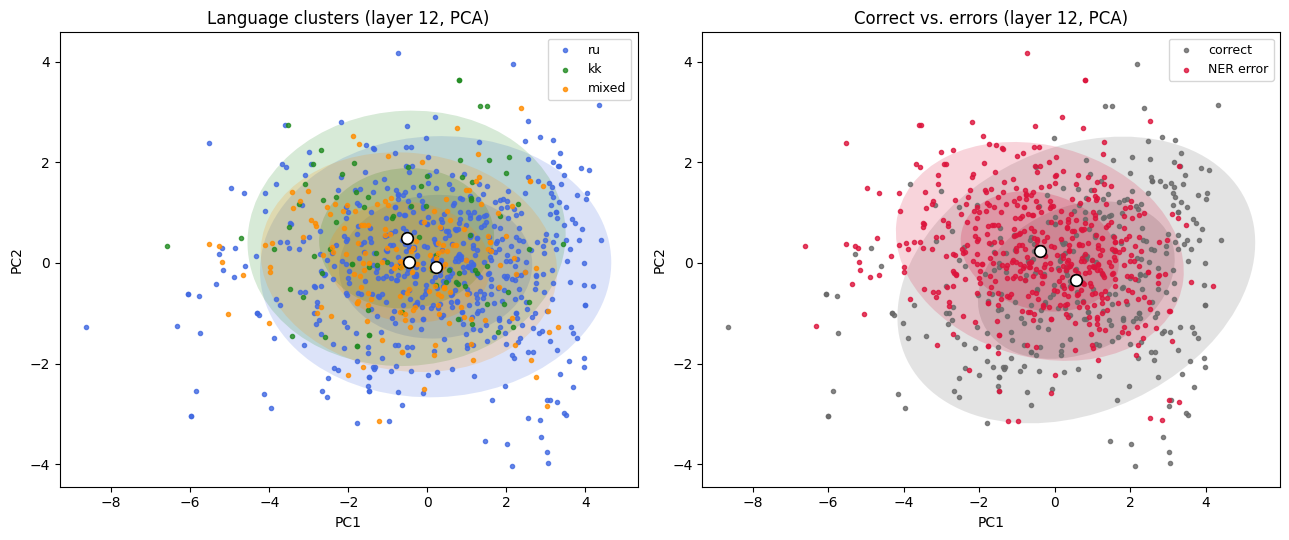

In [29]:
# Cell 14. PCA projection with covariance ellipses; saved to figures/
import os
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

def cluster_ellipse(ax, pts, color, n_std=2.0):
    if len(pts) < 3:
        return
    cov = np.cov(pts.T)
    mean = pts.mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    ax.add_patch(Ellipse(mean, w, h, angle=angle, facecolor=color,
                         edgecolor="none", alpha=0.18, zorder=1))
    ax.add_patch(Ellipse(mean, w * 0.55, h * 0.55, angle=angle, facecolor=color,
                         edgecolor="none", alpha=0.22, zorder=1))

def plot_groups(ax, xy2, groups):
    for mask, color, label, z in groups:
        pts = xy2[mask]
        if len(pts) == 0:
            continue
        cluster_ellipse(ax, pts, color)
        ax.scatter(pts[:, 0], pts[:, 1], s=9, c=color, label=label, alpha=0.8, zorder=z)
        if len(pts) > 2:
            ax.scatter(*pts.mean(axis=0), s=70, c="white", edgecolors="black",
                       linewidths=1.2, zorder=5)
    ax.legend(fontsize=9)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

xy2 = PCA(n_components=2, random_state=SEED).fit_transform(emb_test[PLOT_L])
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_groups(axes[0], xy2, [((df_test["lang"] == g).values, c, g, 2)
                           for g, c in [("ru", "royalblue"), ("kk", "forestgreen"),
                                        ("mixed", "darkorange")]])
axes[0].set_title(f"Language clusters (layer {PLOT_L}, PCA)")
err = df_test["error"].values
plot_groups(axes[1], xy2, [(err == 0, "dimgray", "correct", 2),
                           (err == 1, "crimson", "NER error", 3)])
axes[1].set_title(f"Correct vs. errors (layer {PLOT_L}, PCA)")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/representation_space_pca.png", dpi=200, bbox_inches="tight")
plt.show()

In [30]:
# Cell 15. Does geometry predict errors beyond simple baselines?
# Logistic regression with 5-fold cross-validation, ROC-AUC.
# Key comparison: "geometry + all baselines" vs. "+ model confidence".
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

y = df_test["error"].values
geom_cols = [f"d_own_L{l}" for l in LAYERS] + [f"d_gap_L{l}" for l in LAYERS]
lang_dummies = pd.get_dummies(df_test["lang"], prefix="lang")
base = ["n_tokens", "n_gold_entities"]

feature_sets = {
    "length + n_entities": df_test[base],
    "+ language": pd.concat([df_test[base], lang_dummies], axis=1),
    "+ model confidence": pd.concat([df_test[base + ["conf"]], lang_dummies], axis=1),
    "geometry only": df_test[geom_cols],
    "geometry + all baselines": pd.concat([df_test[geom_cols + base + ["conf"]],
                                           lang_dummies], axis=1),
}

cv = StratifiedKFold(5, shuffle=True, random_state=0)
for name, X in feature_sets.items():
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    proba = cross_val_predict(clf, X.values.astype(float), y, cv=cv,
                              method="predict_proba")[:, 1]
    print(f"{name:28s} AUC = {roc_auc_score(y, proba):.3f}")

# Robustness: geometry-only AUC within each language
print()
for grp in ["ru", "kk", "mixed"]:
    sub = df_test[df_test["lang"] == grp]
    if len(sub) < 40 or sub["error"].nunique() < 2:
        print(f"{grp:6s}: too few examples ({len(sub)}), skipped")
        continue
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    cvg = StratifiedKFold(3, shuffle=True, random_state=0)
    proba = cross_val_predict(clf, sub[geom_cols].values.astype(float), sub["error"].values,
                              cv=cvg, method="predict_proba")[:, 1]
    print(f"{grp:6s}: n={len(sub):4d}  AUC(geometry) = {roc_auc_score(sub['error'].values, proba):.3f}")

length + n_entities          AUC = 0.683
+ language                   AUC = 0.695
+ model confidence           AUC = 0.801
geometry only                AUC = 0.693
geometry + all baselines     AUC = 0.829

ru    : n= 576  AUC(geometry) = 0.705
kk    : n=  82  AUC(geometry) = 0.805
mixed : n= 167  AUC(geometry) = 0.665


## Part 3. Train–test shift measured with the sliced Wasserstein distance

In the published model, STREET_NAME has a low F1, and complaints containing street names are unevenly split (34 train / 167 test). Here we measure the train–test shift of complaint embeddings for complaints containing street names vs. stop names.

**Caveat:** the uneven split itself may produce much of this shift. Part 4 adds the necessary controls.

In [32]:
# Cell 16. Sliced Wasserstein distance (SWD) between train and test embeddings
import ot

def swd(A, B, n_proj=200, seed=0):
    return ot.sliced.sliced_wasserstein_distance(
        A.astype(np.float64), B.astype(np.float64),
        n_projections=n_proj, seed=seed)

L = PLOT_L
print(f"Layer {L}. SWD, train vs. test:")
for cls in ["has_STOP_NAME", "has_STREET_NAME"]:
    tr = emb_train[L][(df_train[cls] == 1).values]
    te = emb_test[L][(df_test[cls] == 1).values]
    print(f"{cls.replace('has_', ''):12s} train n={len(tr):4d}, test n={len(te):4d} -> SWD = {swd(tr, te):.4f}")

# Reference values for scale
ru_tr = emb_train[L][(df_train["lang"] == "ru").values]
ru_te = emb_test[L][(df_test["lang"] == "ru").values]
kk_te = emb_test[L][(df_test["lang"] == "kk").values]
print("\nReference values:")
print(f"ru (train) vs ru (test) -> SWD = {swd(ru_tr, ru_te):.4f}")
print(f"ru (test)  vs kk (test) -> SWD = {swd(ru_te, kk_te):.4f}")

Layer 12. SWD, train vs. test:
STOP_NAME    train n=1616, test n= 462 -> SWD = 0.0419
STREET_NAME  train n=  34, test n= 167 -> SWD = 0.1367

Reference values:
ru (train) vs ru (test) -> SWD = 0.0431
ru (test)  vs kk (test) -> SWD = 0.0720


## Part 4. Statistical controls for Part 3

- **Entity-level embeddings:** mean over the subword tokens of each gold entity span, instead of the whole complaint.
- **Permutation test:** is the train–test SWD larger than for random splits of the same pooled data?
- **Size-matched null:** SWD of STOP_NAME on subsamples of the same size as STREET_NAME (small samples inflate SWD).
- **Frozen vs. fine-tuned encoder:** separates data shift from memorization of the training set.
- **Language composition** of complaints with street names in train and test.

In [33]:
# Cell 17. Statistical controls for the SWD analysis
# Requires: model, train_loader, test_loader, df_train, df_test, emb_train, emb_test,
#           id2label, DEVICE, swd, LAYERS (cells 1-16).
from transformers import XLMRobertaModel

N_PERM = 500   # permutations (p-value resolution about 0.002)
N_REP = 200    # subsamples for the size-matched null
rng = np.random.default_rng(0)


def entity_embs(loader, encoder, ent_type, layer):
    """One vector per gold entity of ent_type: mean over all its subword tokens."""
    vecs = []
    encoder.eval()
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            attn = batch["attention_mask"].to(DEVICE)
            out = encoder(input_ids=ids, attention_mask=attn, output_hidden_states=True)
            H = out.hidden_states[layer].cpu().numpy()
            labels = batch["labels"]
            for i in range(labels.size(0)):
                pos = [j for j in range(labels.size(1)) if labels[i][j] != -100]
                tags = [id2label[labels[i][j].item()] for j in pos]
                seq_end = int(attn[i].sum().item()) - 1          # exclude </s>
                for t, s, e in get_entities(tags):
                    if t != ent_type:
                        continue
                    end = pos[e + 1] if e + 1 < len(pos) else seq_end
                    vecs.append(H[i, pos[s]:end].mean(axis=0))
    return np.array(vecs)


def perm_test(A, B, n_perm=N_PERM):
    """Observed SWD, mean SWD under random re-splits of the pooled data, and p-value."""
    obs = swd(A, B)
    pooled = np.vstack([A, B])
    na = len(A)
    null = np.empty(n_perm)
    for k in range(n_perm):
        idx = rng.permutation(len(pooled))
        null[k] = swd(pooled[idx[:na]], pooled[idx[na:]])
    p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    return obs, null.mean(), p


def size_matched(A_big, B_big, na, nb, n_rep=N_REP):
    """SWD of a well-represented class on subsamples of the given sizes."""
    return np.array([
        swd(A_big[rng.choice(len(A_big), na, replace=False)],
            B_big[rng.choice(len(B_big), nb, replace=False)])
        for _ in range(n_rep)
    ])


frozen = XLMRobertaModel.from_pretrained("xlm-roberta-base").to(DEVICE)

rows = []
for enc_name, enc in [("fine-tuned", model), ("frozen", frozen)]:
    for layer in LAYERS:
        E = {}
        for split, ld in [("train", train_loader), ("test", test_loader)]:
            for t in ["STOP_NAME", "STREET_NAME"]:
                E[(split, t)] = entity_embs(ld, enc, t, layer)
        st_tr, st_te = E[("train", "STREET_NAME")], E[("test", "STREET_NAME")]
        sp_tr, sp_te = E[("train", "STOP_NAME")], E[("test", "STOP_NAME")]

        obs_st, null_st, p_st = perm_test(st_tr, st_te)
        obs_sp, null_sp, p_sp = perm_test(sp_tr, sp_te)
        matched = size_matched(sp_tr, sp_te, len(st_tr), len(st_te))

        rows.append({
            "encoder": enc_name, "layer": layer,
            "n_street(tr/te)": f"{len(st_tr)}/{len(st_te)}",
            "SWD_street": round(obs_st, 4), "perm_null_street": round(null_st, 4), "p_street": round(p_st, 4),
            "SWD_stop": round(obs_sp, 4), "perm_null_stop": round(null_sp, 4), "p_stop": round(p_sp, 4),
            "stop_size_matched_mean": round(matched.mean(), 4),
            "stop_size_matched_95%": round(np.percentile(matched, 95), 4),
            "street_above_matched_%": round(100 * (matched < obs_st).mean(), 1),
        })

res = pd.DataFrame(rows)
pd.set_option("display.width", 250)
print(res.to_string(index=False))
res.to_csv("swd_checks.csv", index=False)

# Language composition of complaints with STREET_NAME
print("\nLanguage of complaints with STREET_NAME (shares):")
for split, d in [("train", df_train), ("test", df_test)]:
    sub = d[d.has_STREET_NAME == 1]
    print(f"{split:5s} n={len(sub):4d}", sub["lang"].value_counts(normalize=True).round(2).to_dict())

# STREET_NAME shift within Russian-only complaints: if it stays large,
# language mixing is not the main cause.
m_tr = ((df_train.has_STREET_NAME == 1) & (df_train.lang == "ru")).values
m_te = ((df_test.has_STREET_NAME == 1) & (df_test.lang == "ru")).values
if m_tr.sum() >= 5 and m_te.sum() >= 5:
    obs, null_mean, p = perm_test(emb_train[12][m_tr], emb_test[12][m_te])
    print(f"\nru-only STREET complaints, layer 12: SWD={obs:.4f}, permutation null={null_mean:.4f}, p={p:.4f}")
else:
    print("\nru-only STREET complaints: too few examples for a test")

# How to read the results:
#   p_street < 0.05              -> the train-test shift for street names is significant
#   street_above_matched_% > 95  -> it exceeds STOP_NAME at the same sample size,
#                                   so it is not only a small-sample effect
#   shift also with frozen       -> the shift is in the data, not only memorization
#   fine-tuned >> frozen         -> most of the "shift" comes from fitting the train set
#   ru-only also significant     -> language mixing is not the main cause

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   encoder  layer n_street(tr/te)  SWD_street  perm_null_street  p_street  SWD_stop  perm_null_stop  p_stop  stop_size_matched_mean  stop_size_matched_95%  street_above_matched_%
fine-tuned      0          46/208      0.0463            0.0395     0.010    0.0158          0.0130   0.002                  0.0390                 0.0420                   100.0
fine-tuned      4          46/208      0.1142            0.0891     0.002    0.0397          0.0279   0.002                  0.0875                 0.0951                   100.0
fine-tuned      8          46/208      0.2815            0.0957     0.002    0.0691          0.0279   0.002                  0.1035                 0.1152                   100.0
fine-tuned     12          46/208      0.6686            0.1320     0.002    0.1487          0.0369   0.002                  0.1712                 0.2030                   100.0
    frozen      0          46/208      0.0463            0.0398     0.012    0.0158          0.0130   0.0